In [137]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
np.random.seed(0)

m = 2
b = 1

def plot_loss(history):
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title("Training history")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def gen_dataset(f, n_sample, x_range=(-1, 1), sigma=0.2):
    x = np.random.uniform(x_range[0], x_range[1], n_sample)
    y = np.random.normal(f(x), sigma)
    return x, y

def gen_dataset_2d(f, n_sample, x_range=(-1.5, 1.5), y_range=(-1.5, 1.5), sigma=0.2):
    x = np.random.uniform(*x_range, n_sample)
    y = np.random.uniform(*y_range, n_sample)

    z = np.random.normal(f(x, y), sigma)

    return x, y, z

def plotting_function(x, perf, para, xlabel):
    fig, ax = plt.subplots(3, 1, figsize=(10, 12))

    # LOSS
    ax[0].plot(x, perf[:, 0], label='Train')
    ax[0].plot(x, perf[:, 1], label='Test')
    ax[0].set_title("Model loss")
    ax[0].set_xlabel(xlabel)
    ax[0].set_ylabel("Loss")
    ax[0].legend()
    ax[0].grid(True)

    # SLOPE
    ax[1].plot(x, para[:,0], label='Learned slope')
    ax[1].axhline(m, linestyle='--', label='True slope')
    ax[1].set_title("Slope parameter")
    ax[1].set_xlabel(xlabel)
    ax[1].set_ylabel("w")
    ax[1].legend()
    ax[1].grid(True)

    ax[2].plot(x, para[:,1], label='Learned bias')
    ax[2].axhline(b, linestyle='--', label='True bias')
    ax[2].set_title("Bias parameter")
    ax[2].set_xlabel(xlabel)
    ax[2].set_ylabel("b")
    ax[2].legend()
    ax[2].grid(True)

    plt.tight_layout()
    plt.show()


<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 11
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
Introduction to machine learning
</h2>

<h1 style="color: blue; font-size: 25px; font-weight: bold;">
Prediction problem
</h1>

Consider a probabilistic process that gives rise to labeled data $(x, y)$. The data is generated by drawing samples from the equation
$$
y_i=f(x_i)+\eta _i
$$
where $f(x)$ is some fixed, but (possibly unknown) function, and $\eta$ is a Gaussian, uncorrelated noise variable such that
$$
\braket{\eta _i} = 0; \ \braket{\eta _i\eta _j}=\delta _{ij}\sigma^2
$$
To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model represent the model class that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a different dataset, the **validation data set**. The reason we must divide our data into a training and test datasets is that the point of machine learning is to make accurate predictions about new data we have not seen.

One common measure of predictive performance of our algorithm is to compare the predictions of the NN, $\{y^{pred}_j\}$, to the true values $\{y_j\}$
. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE = \frac{1}{N}\sum_{i=1}^N(y^{pred}_i-y_i)^2
$$

<h1 style="color: blue; font-size: 25px; font-weight: bold;">
11.1: Linear fit
</h1>

In the first part of the excercise, the function to be learned is the simplest
$$
f(x)=2x+1.
$$
The true function is generated, and then the training dataset is obtained by adding some random (Gaussian) noise.

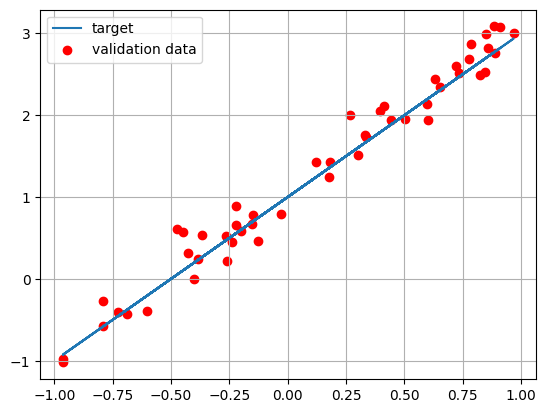

In [138]:
def retta(x):
    return m*x + b

x_train, y_train = gen_dataset(retta, 500) 
x_valid, y_valid = gen_dataset(retta, 50)
#x_valid.sort()
x_target = np.linspace(-1, 1, 100)
y_target = m * x_valid + b # ideal (target) linear function

plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

Only one neuron (2 parameters) is sufficient to learn a linear function, because it already behaves like a linear function itself.

In [139]:
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

def create_one_neuron_model():
    model = tf.keras.Sequential()
    model.add(Input(shape=(1,)))
    model.add(Dense(1))
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])
    return model

model=create_one_neuron_model()
model.summary()

Model: "sequential_2527"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2551 (Dense)              │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

The training is performed on a batch size of 32 data points and in 30 epochs.

In [140]:
history = model.fit(x=x_train, y=y_train, batch_size=32, epochs=30, shuffle=True, validation_data=(x_valid, y_valid))

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5966 - mse: 1.5966 - val_loss: 1.6112 - val_mse: 1.6112
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0641 - mse: 1.0641 - val_loss: 1.1272 - val_mse: 1.1272
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7541 - mse: 0.7541 - val_loss: 0.8125 - val_mse: 0.8125
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5339 - mse: 0.5339 - val_loss: 0.6070 - val_mse: 0.6070
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4130 - mse: 0.4130 - val_loss: 0.4668 - val_mse: 0.4668
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3093 - mse: 0.3093 - val_loss: 0.3687 - val_mse: 0.3687
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2707 - mse: 0.2707 - val_loss: 0.2971 - val_mse: 0.2971
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2087 - mse: 0.2087 - val_loss: 0.2436 - val_mse: 0.2436
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1755 - mse: 

The final neural network weights are shown below. As can be seen, they are close to the coefficients of the target function.

In [141]:
weights, bias = model.get_weights()
print("Weight: ", weights)
print("Bias: ", bias)

Weight:  [[1.9449161]]
Bias:  [0.97976416]


In [142]:
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0493 - mse: 0.0493
Test loss: 0.04880784824490547
Test accuracy: 0.04880784824490547


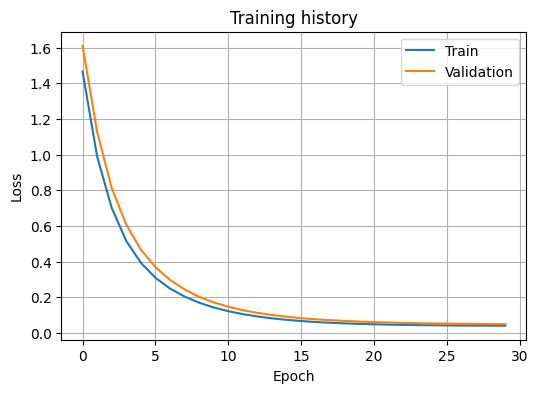

In [143]:
# Plot training & validation loss values
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


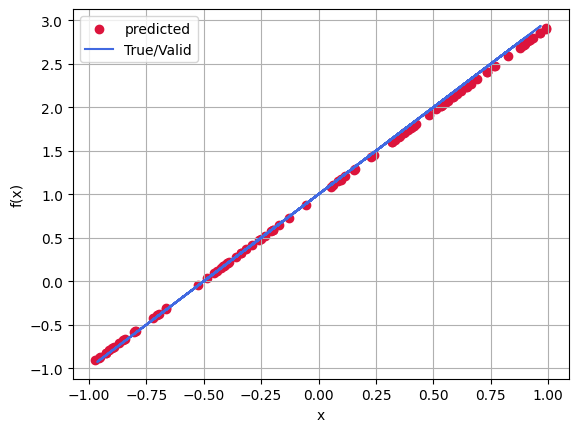

In [144]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted, color='crimson', label='predicted')
plt.plot(x_valid, y_target, color='royalblue', label='True/Valid')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

Let's try to see how the loss function vary with the number of training points

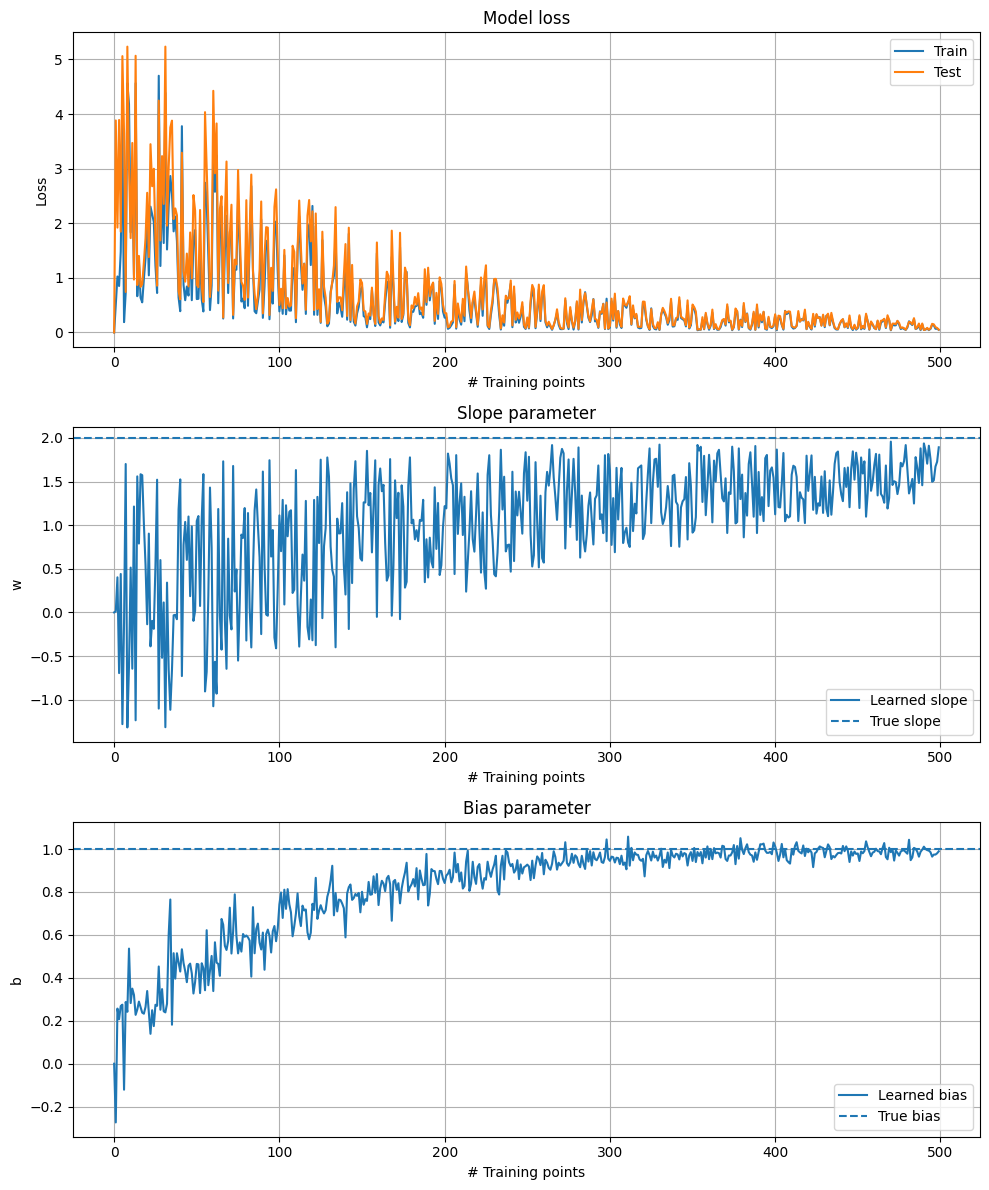

In [145]:
N_max = 500
N = np.arange(N_max)
param = np.zeros((N_max, 2))
performance = np.zeros((N_max, 2))

for n in range(1, N_max):
    x_train, y_train = gen_dataset(retta, n) # the same as before

    model_n = create_one_neuron_model()
    history = model_n.fit(x=x_train, y=y_train,
                        batch_size=32, epochs=15,
                        shuffle=True, verbose=0,
                        validation_data=(x_valid, y_valid))
    weights, biases = model_n.get_weights()
    param[n, 0] = weights[0, 0]
    param[n, 1] = biases[0]

    performance[n][0] = history.history['loss'][-1]
    performance[n][1] = history.history['val_loss'][-1]

plotting_function(N, performance, param, "# Training points")

Now we study how the regression depend on the noise $\sigma$.

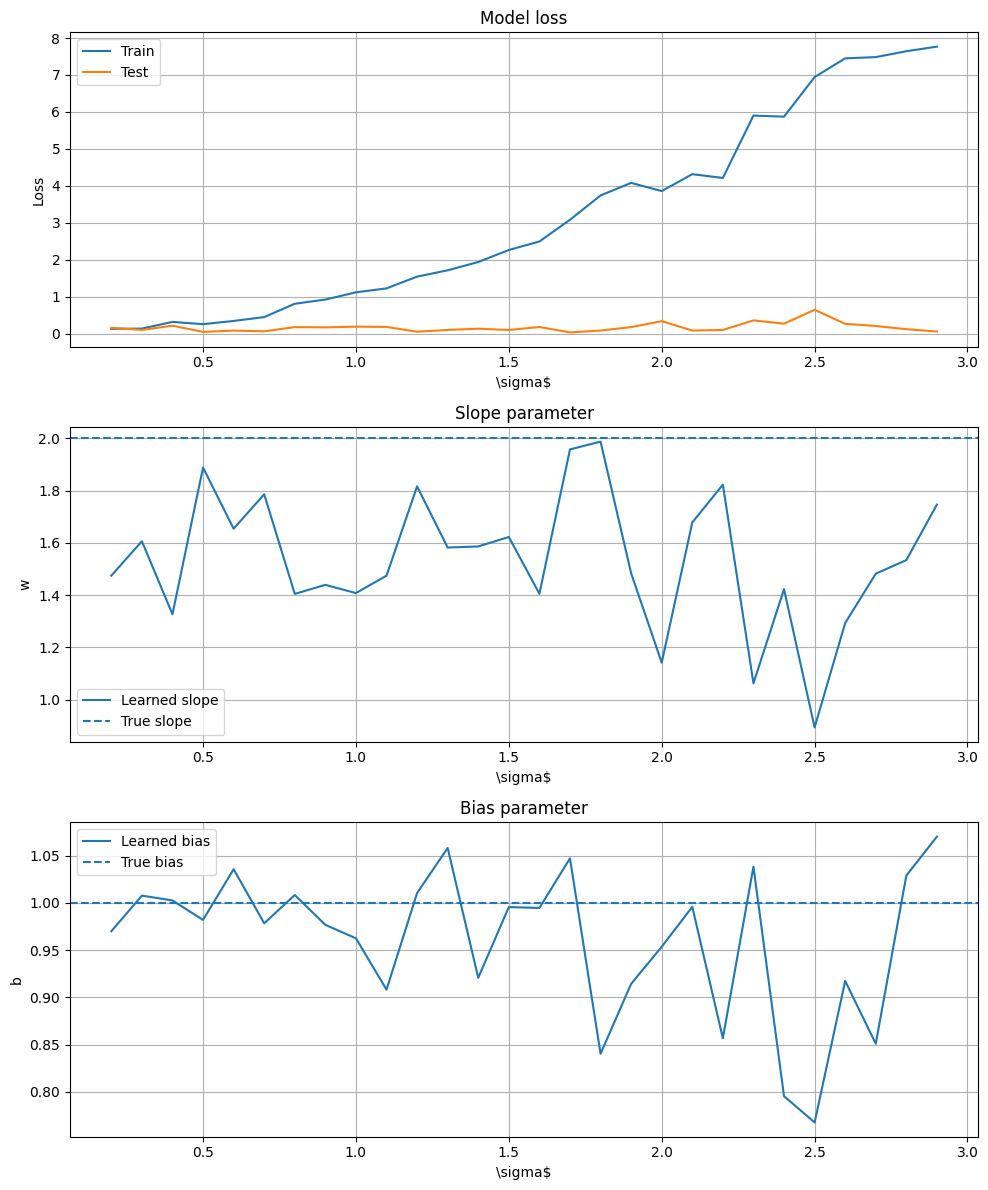

In [146]:
sigma = np.arange(0.2, 3.0, 0.1)
param = np.zeros((len(sigma), 2))
performance = np.zeros((len(sigma), 2))
for n, s in enumerate(sigma):
    x_train, y_train = gen_dataset(retta, 500, (-1, 1), s)#generate_training_set(500, s) # the same as before

    model = create_one_neuron_model()
    history = model.fit(x=x_train, y=y_train,
                        batch_size=32, epochs=15,
                        shuffle=True, verbose=0,
                        validation_data=(x_valid, y_valid))
    weights, biases = model.get_weights()
    param[n, 0] = weights[0, 0]
    param[n, 1] = biases[0]

    performance[n][0] = history.history['loss'][-1]#model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)
    performance[n][1] = history.history['val_loss'][-1]

plotting_function(sigma, performance, param, r"\sigma$")

<h1 style="color: blue; font-size: 25px; font-weight: bold;">
11.2
</h1>

Now we extend the model to obtain a reasonable fit of the following polynomial of order 3:
$$
f(x)=4-3x-2x^2+3x^3, \quad x\in[-1, 1].
$$
Of course, the one-neuron model isn't enough anymore, since the function isn't linear. The model is now extended to an MLP with two layers of 16 neurons each with Relu activation, and a single neuron output layer to generate the single valued predictions.

The data is generated in the same way as before, and the training is performed on a batch size of 32 in 15 epochs.

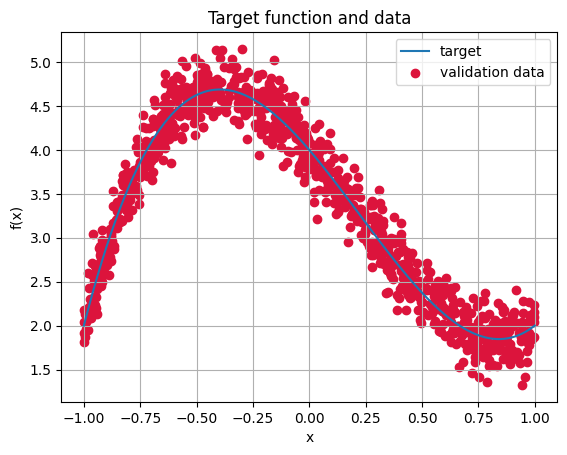

In [147]:
def f(x):
    return 4 - 3*x -2*x**2 + 3*x**3

x_train, y_train = gen_dataset(f, 10000)
x_valid, y_valid = gen_dataset(f, 1000)
x_target = np.linspace(-1, 1, 500)
y_target = f(x_target)

# plot validation and target dataset
plt.plot(x_target, y_target, label='target')
plt.scatter(x_valid, y_valid, color='crimson', label='validation data')
plt.title("Target function and data")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

The optimizer used is SGD with fixed learning rate 0.01. ReLu activation function is used.

In [148]:
def create_MLP_model(in_shape, N_layers, N_n_per_layer, activ, optim): # activ could be 'relu', 'sigmoid' or else
    model_mlp = Sequential()
    model_mlp.add(Input(shape=in_shape))
    for l in range(N_layers):
        model_mlp.add(Dense(N_n_per_layer, activation=activ))
    model_mlp.add(Dense(1))
    model_mlp.compile(optimizer=optim, loss='mse', metrics=['mse'])
    return model_mlp

model = create_MLP_model((1,), 2, 16, 'relu', tf.keras.optimizers.SGD(learning_rate=0.01))
model.summary()

Model: "sequential_3055"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3079 (Dense)              │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3080 (Dense)              │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3081 (Dense)              │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [149]:
history = model.fit(x=x_train, y=y_train,
                    batch_size=32, epochs=15,
                    shuffle=True, #good idea shuffle the input before of each epoch, to get best randomicity
                    validation_data=(x_valid, y_valid))

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - loss: 2.9894 - mse: 2.9894 - val_loss: 0.1828 - val_mse: 0.1828
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step - loss: 0.1275 - mse: 0.1275 - val_loss: 0.0819 - val_mse: 0.0819
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - loss: 0.0706 - mse: 0.0706 - val_loss: 0.0608 - val_mse: 0.0608
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - loss: 0.0556 - mse: 0.0556 - val_loss: 0.0522 - val_mse: 0.0522
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - loss: 0.0489 - mse: 0.0489 - val_loss: 0.0497 - val_mse: 0.0497
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step - loss: 0.0464 - mse: 0.0464 - val_loss: 0.0464 - val_mse: 0.0464
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step - loss: 0.0443 - mse: 0.0443 - val_loss: 0.0454 - val_mse: 0.0454
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - loss: 0.0431 - mse: 0.0431 - val_loss: 0.0461 - val_mse: 0.0461
Epoch 9/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 

In [150]:
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0327 - mse: 0.0327

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - loss: 0.0392 - mse: 0.0392

Test loss: 0.0430682934820652
Test accuracy: 0.0430682934820652


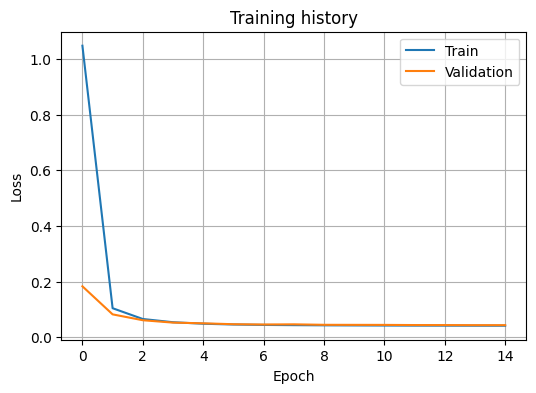

In [151]:
plot_loss(history)

In this section, the model’s ability to generalize was tested by evaluating it on intervals of $f(x)$ different from those used during training. While the model performs accurately within the training range, its predictions fail to generalize outside of it.

Increasing complexity (by adding layers or neurons) enhances the model’s ability to fit the training data and reduces training error.
However, greater complexity does not guarantee improved generalization, particularly outside the training domain.

Neural networks are strong interpolators but weak extrapolators: their predictive power is fundamentally tied to the distribution of the data on which they are trained.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step


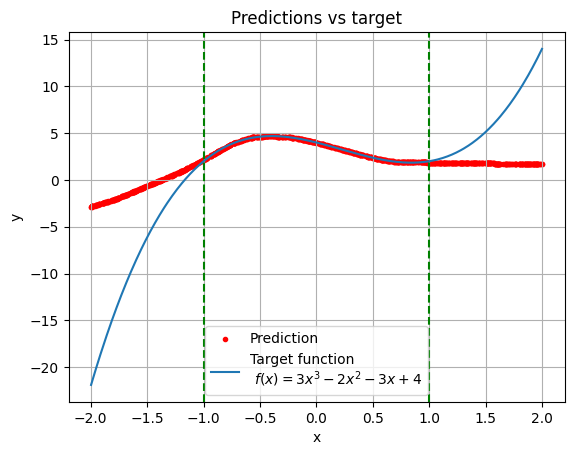

In [152]:
x_predicted = np.random.uniform(-2, 2, 1000)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r', marker='.', label='Prediction')
x_predicted.sort()
y_target = f(x_predicted)
plt.axvline(1., color='g', linestyle='--')
plt.axvline(-1., color='g', linestyle='--')
plt.title("Predictions vs target")
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x_predicted, y_target, label="Target function\n $f(x) = 3x^3 - 2x^2 - 3x + 4$")
plt.legend()
plt.grid(True)
plt.show()

The same regression is perfomed also with an other optimizer, like Adam. Adam combines the advantages of Momentum (keeps track of past gradients) and RMSProp (adapts learning rate per parameter).

In [153]:
model = create_MLP_model((1,), 2, 16, 'relu', tf.keras.optimizers.Adam())
model.summary()
history = model.fit(x=x_train, y=y_train,
                    batch_size=32, epochs=15,
                    shuffle=True, #good idea shuffle the input before of each epoch, to get best randomicity
                    validation_data=(x_valid, y_valid))

Model: "sequential_3056"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3082 (Dense)              │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3083 (Dense)              │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3084 (Dense)              │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - loss: 6.7449 - mse: 6.7449 - val_loss: 0.6355 - val_mse: 0.6355
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.4664 - mse: 0.4664 - val_loss: 0.1943 - val_mse: 0.1943
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - loss: 0.1383 - mse: 0.1383 - val_loss: 0.0807 - val_mse: 0.0807
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 0.0666 - mse: 0.0666 - val_loss: 0.0572 - val_mse: 0.0572
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step - loss: 0.0539 - mse: 0.0539 - val_loss: 0.0529 - val_mse: 0.0529
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - loss: 0.0492 - mse: 0.0492 - val_loss: 0.0502 - val_mse: 0.0502
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - loss: 0.0450 - mse: 0.0450 - val_loss: 0.0487 - val_mse: 0.0487
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.0453 - mse: 0.0453 - val_loss: 0.0463 - val_mse: 0.0463
Epoch 9/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - loss: 0.0428 - mse: 0.0428

Test loss: 0.04737826809287071
Test accuracy: 0.04737826809287071


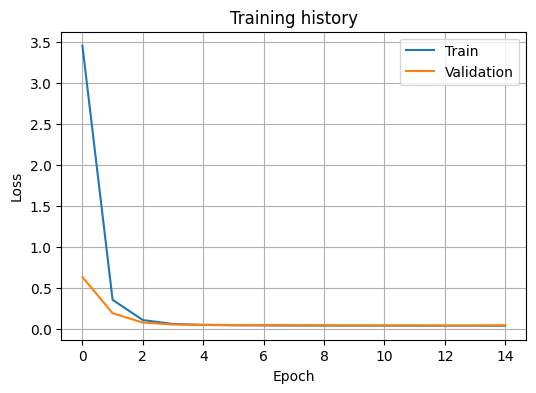

In [154]:
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])
plot_loss(history)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step


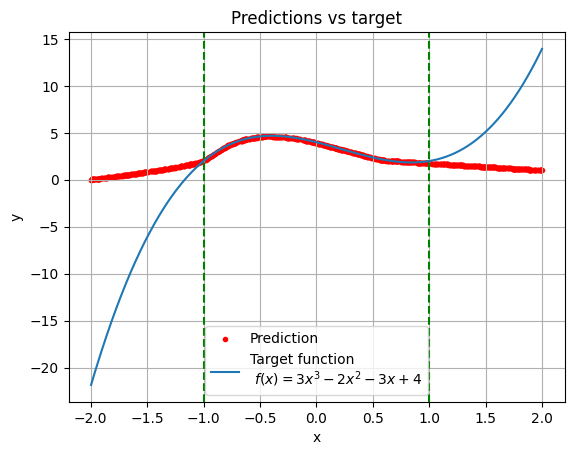

In [155]:
x_predicted = np.random.uniform(-2, 2, 1000)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r', marker='.', label='Prediction')
x_predicted.sort()
y_target = f(x_predicted)
plt.axvline(1., color='g', linestyle='--')
plt.axvline(-1., color='g', linestyle='--')
plt.title("Predictions vs target")
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x_predicted, y_target, label="Target function\n $f(x) = 3x^3 - 2x^2 - 3x + 4$")
plt.legend()
plt.grid(True)
plt.show()

We found that the Adam optimizer outperforms SGD only in terms of convergence speed, reaching the minimum much faster. However, their final performance scores and predictions are very similar, and in both cases, the NN proves to be a poor extrapolator.

<h1 style="color: blue; font-size: 25px; font-weight: bold;">
11.3:
</h1>

Try to extend the model to fit a simple trigonometric 2D function such as $f(x)=sin(x^2+y^2)$ in the range $x\in[-3/2, 3/2]$ and $y\in[-3/2, 3/2]$.


Generated data, training and model performance are shown below.

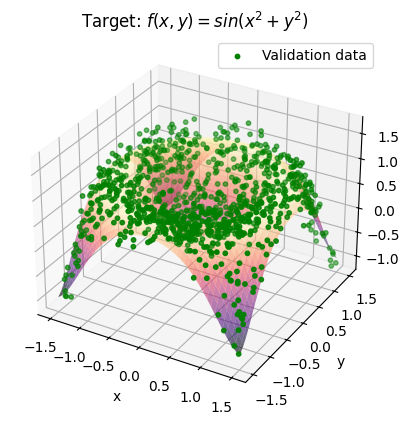

In [161]:
def f2(x, y):
    return np.sin(x**2 + y**2)

x_train, y_train, z_train = gen_dataset_2d(f2, 10000)
x_valid, y_valid, z_valid = gen_dataset_2d(f2, 1000)

X_plot, Y_plot = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
z_target = f2(X_plot, Y_plot)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_plot, Y_plot, z_target, cmap='magma', alpha=0.6)
ax.scatter(x_valid, y_valid, z_valid, color='green', s=10, label='Validation data')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(r"Target: $f(x,y) = sin(x^2 + y^2)$")
ax.legend()
plt.show()

For this task, the model built consists in two layers of 50 neurons each, and a final otput layer with a single neuron.

Also for this case, the best activation function found was the Relu, which performed slightly better than the sigmoid.

The optimizer used is again the SGD, since the task was similar to the previous one.

In [167]:
model_3d = create_MLP_model((2,), 2, 50, 'relu', tf.keras.optimizers.SGD(learning_rate=0.01))

model_3d.summary()
X_train = np.column_stack((x_train, y_train))
X_val = np.column_stack((x_valid, y_valid))

history = model_3d.fit(X_train, z_train, batch_size=32,
                       epochs=20, shuffle=True, #good idea shuffle the input before of each epoch, to get best randomicity
                       validation_data=(X_val, z_valid))

Model: "sequential_3062"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3100 (Dense)              │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3101 (Dense)              │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3102 (Dense)              │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751 (10.75 KB)

 Trainable params: 2,751 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 0.3016 - mse: 0.3016 - val_loss: 0.1869 - val_mse: 0.1869
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - loss: 0.1751 - mse: 0.1751 - val_loss: 0.1798 - val_mse: 0.1798
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - loss: 0.1598 - mse: 0.1598 - val_loss: 0.1705 - val_mse: 0.1705
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 430us/step - loss: 0.1533 - mse: 0.1533 - val_loss: 0.1637 - val_mse: 0.1637
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step - loss: 0.1406 - mse: 0.1406 - val_loss: 0.1556 - val_mse: 0.1556
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - loss: 0.1428 - mse: 0.1428 - val_loss: 0.1479 - val_mse: 0.1479
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - loss: 0.1328 - mse: 0.1328 - val_loss: 0.1398 - val_mse: 0.1398
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - loss: 0.1263 - mse: 0.1263 - val_loss: 0.1310 - val_mse: 0.1310
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step


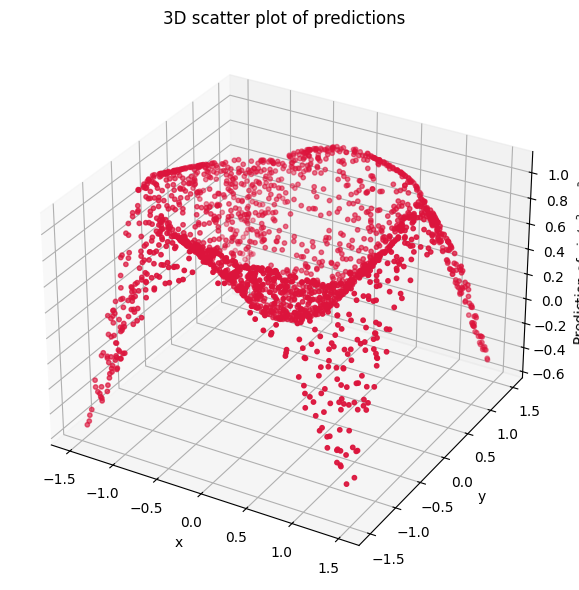

In [168]:
x_predicted = np.random.uniform(-1.5, 1.5, 2000)
y_predicted = np.random.uniform(-1.5, 1.5, 2000)
X_predicted = np.column_stack((x_predicted, y_predicted))
z_predicted = model_3d.predict(X_predicted)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_predicted[:, 0], X_predicted[:, 1], z_predicted.flatten(), c='crimson', s=10)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel(r"Prediction of $sin(x^2+y^2)$")
ax.set_title("3D scatter plot of predictions")

plt.tight_layout()
plt.show()

A comparison of the same regression with the same number of layer and neurons per layers but dufferent activation function (Sigmoid) is shown below

In [169]:
model_3d = create_MLP_model((2,), 2, 50, 'sigmoid', tf.keras.optimizers.SGD(learning_rate=0.01))

model_3d.summary()
X_train = np.column_stack((x_train, y_train))
X_val = np.column_stack((x_valid, y_valid))

history = model_3d.fit(X_train, z_train, batch_size=32,
                       epochs=20, shuffle=True, #good idea shuffle the input before of each epoch, to get best randomicity
                       validation_data=(X_val, z_valid))

Model: "sequential_3063"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3103 (Dense)              │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3104 (Dense)              │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3105 (Dense)              │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,751 (10.75 KB)

 Trainable params: 2,751 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 0.2673 - mse: 0.2673 - val_loss: 0.2032 - val_mse: 0.2032
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 0.1845 - mse: 0.1845 - val_loss: 0.2021 - val_mse: 0.2021
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - loss: 0.1873 - mse: 0.1873 - val_loss: 0.1996 - val_mse: 0.1996
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - loss: 0.1892 - mse: 0.1892 - val_loss: 0.2018 - val_mse: 0.2018
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - loss: 0.1840 - mse: 0.1840 - val_loss: 0.1999 - val_mse: 0.1999
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - loss: 0.1802 - mse: 0.1802 - val_loss: 0.2009 - val_mse: 0.2009
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.1809 - mse: 0.1809 - val_loss: 0.2011 - val_mse: 0.2011
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - loss: 0.1898 - mse: 0.1898 - val_loss: 0.2058 - val_mse: 0.2058
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step


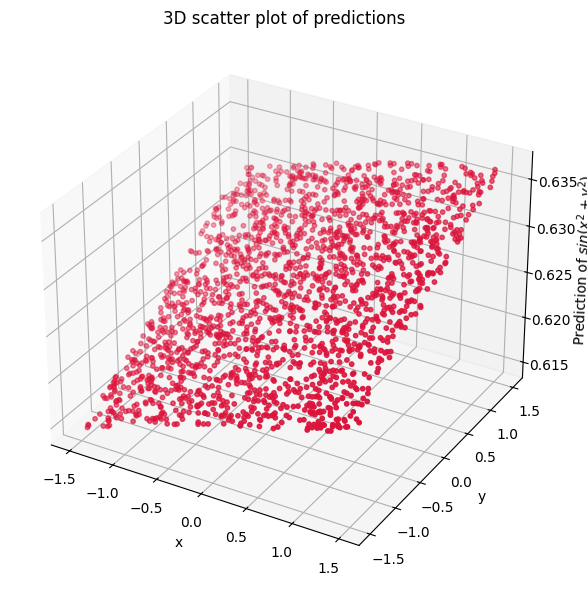

In [170]:
x_predicted = np.random.uniform(-1.5, 1.5, 2000)
y_predicted = np.random.uniform(-1.5, 1.5, 2000)
X_predicted = np.column_stack((x_predicted, y_predicted))
z_predicted = model_3d.predict(X_predicted)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_predicted[:, 0], X_predicted[:, 1], z_predicted.flatten(), c='crimson', s=10)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel(r"Prediction of $sin(x^2+y^2)$")
ax.set_title("3D scatter plot of predictions")

plt.tight_layout()
plt.show()

The Sigmoid function performs poorly here due to the vanishing gradient problem. Because its derivative approaches zero for not very large inputs, the weights stop updating during backpropagation, trapping the network in a poor local minimum. Additionally, its bounded output between (0,1) makes it inefficient at capturing the unbounded, oscillating nature of this 3D target function.

Conversely, the ReLU activation function avoids this issue because it does not saturate for positive inputs, allowing for significantly accurate convergence.